# Observable → f_b — **beam-aware training** (v2)

**⚠️ Provisional.** Same caveats as the previous three notebooks (single subgrid family,
fixed cosmology, projected stacks). This notebook fixes one specific brittleness uncovered
in `profile_fb_ysz_ksz.ipynb` §5: when the BIND-trained Ridge map is fed truth observables
that have been beamed and miscentred, the prediction *gets worse* with kSZ added — a
classic train/test domain shift, because training never saw the instrumental smoothing.

### The single experiment
Apply the **same forward model** (beam + miscentering as a 2D Gaussian smoothing of width
`σ_total = √(σ_beam² + σ_cen²)`) to the **256 BIND training designs** before fitting Ridge,
then evaluate against beamed truth observables at the *matched* beam FWHM. This is what a
real experiment would do: train on simulations forward-modelled to the instrument it will
be evaluated against.

Concretely, at each assumed beam FWHM `θ_b ∈ {0′, 1.0′, 1.6′, 2.5′}`:
1. Forward-model all 256 BIND `(Y, kSZ)` design profiles → `Bp_beam[θ_b]`.
2. Refit the Ridge map on `Bp_beam[θ_b]` (clean targets `f_b` are unchanged — the target
   is the *intrinsic* baryon fraction; only the inputs are beamed).
3. Forward-model the truth observables at the same beam, add per-radius lognormal noise,
   predict `f_b(r)`, compute RMS|pred − truth|.
4. Also redo the held-out-feedback K-fold reduction so we can read off the
   **information loss as a function of beam FWHM** in BIND-land alone.

### What this notebook gives that v1 didn't
- A **beam–FWHM → recovered-RMS curve** that an experiment proposal can actually use
  ("to reach `σ_marg`-level recovery you need FWHM ≤ X kpc/h").
- A clean test of whether the Y+kSZ uplift survives instrumental smoothing once training
  is matched.

### What is *still* not done (carry to write-up)
- No off-grid (SIMBA / Astrid / EAGLE) test.
- No cosmology / redshift marginalisation.
- No real-data demo.
- Miscentering still modelled as 2D Gaussian; real distributions are bimodal.
- kSZ noise still flat lognormal; pairwise-kSZ covariance is correlated.

## 0. Load + reuse the v1 helpers
Same data sources as `profile_fb_ysz_ksz.ipynb`. Requires the kSZ cache built by
`tools/stack_gas_column.py`.

In [11]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

SOBOL = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/observable_fb_beam_aware'); FIG.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(3)

B = np.load(SOBOL/'stacked_profiles.npz', allow_pickle=True)
T = np.load(SOBOL/'truth_stacked_profiles.npz', allow_pickle=True)
GAS = np.load(SOBOL/'gas_column_profile.npz')
r = B['r_kpc']; MLBL = list(B['mass_lbl']); nr = len(r)
PIX_KPC_H = 50.0/1024.0*1000.0

# clean BIND design inputs + target
Bp_clean = {'Y': B['Y'], 'kSZ': GAS['gas_mean'], 'fb': B['fb']}      # (256,3,nr)
OBS_COLS = ['Y', 'kSZ']
LOGFEAT = {'Y', 'kSZ'}

# truth aggregation (identical to v1 §1)
KEYS = ['y_sum','SX_sum','gas_sum','baryon_sum','tot_sum','Tgas_sum','Sgas_sum','Pgas_sum']
S_ = {k: T[k] for k in KEYS}; cnt_sb = T['counts']; nsim = cnt_sb.shape[0]
def aggregate(sim_sel):
    w = np.zeros(3); acc = {k: np.zeros((3, nr)) for k in KEYS}
    for s in sim_sel:
        for k in KEYS: acc[k] += np.nan_to_num(S_[k][s])
        w += cnt_sb[s]
    return dict(Y=acc['y_sum']/w[:, None],
                kSZ=acc['gas_sum']/w[:, None],
                fb=acc['baryon_sum']/acc['tot_sum'])
truth = aggregate(np.arange(nsim))
boot = [aggregate(RNG.integers(0, nsim, nsim)) for _ in range(300)]
def band(name):
    A = np.array([b[name] for b in boot]); return np.percentile(A, [16, 84], 0)

print('designs', Bp_clean['Y'].shape[0], '| truth sims', nsim,
      '| pixel scale', f'{PIX_KPC_H:.2f} kpc/h')

designs 256 | truth sims 26 | pixel scale 48.83 kpc/h


## 1. Forward-model helpers (same as v1, kept self-contained)
The 2D-smoothing operator + lognormal noise + (optional) 2-halo offset, identical
to `profile_fb_ysz_ksz.ipynb` §4 so results are directly comparable. The empty-annulus
patch (linear interp in log r) is included.

In [12]:
_GRID = 256
_xx, _yy = np.meshgrid(np.arange(_GRID)-_GRID/2+0.5, np.arange(_GRID)-_GRID/2+0.5)
_RR_KPC = np.sqrt(_xx**2 + _yy**2) * PIX_KPC_H

def _radial_to_2d(P, r_kpc):
    return np.interp(_RR_KPC.ravel(), r_kpc, P, left=P[0], right=P[-1]).reshape(_GRID, _GRID)

def _azim_avg(im, r_kpc):
    re = np.geomspace(r_kpc[0]/np.sqrt(r_kpc[1]/r_kpc[0]),
                       r_kpc[-1]*np.sqrt(r_kpc[-1]/r_kpc[-2]), len(r_kpc)+1)
    out = np.full(len(r_kpc), np.nan); flat = im.ravel(); rr = _RR_KPC.ravel()
    for i in range(len(r_kpc)):
        m = (rr >= re[i]) & (rr < re[i+1])
        if m.any(): out[i] = flat[m].mean()
    if np.isnan(out).any():
        good = ~np.isnan(out)
        if good.sum() >= 2:
            out[~good] = np.interp(np.log(r_kpc[~good]), np.log(r_kpc[good]), out[good])
    return out

def smooth_profile(P, r_kpc, sigma_kpc):
    if sigma_kpc <= 0: return P.copy()
    im = _radial_to_2d(P, r_kpc)
    im_s = gaussian_filter(im, sigma=sigma_kpc/PIX_KPC_H, mode='nearest')
    return _azim_avg(im_s, r_kpc)

def lognormal_noise(P, r_kpc, f_in=0.05, f_out=0.40, rng=None):
    rng = rng or np.random.default_rng()
    t = (np.log(r_kpc) - np.log(r_kpc[0])) / (np.log(r_kpc[-1]) - np.log(r_kpc[0]))
    sig = f_in + (f_out - f_in) * t
    return P * np.exp(rng.normal(0, sig))

def smooth_designs(Bp, sigma_kpc):
    '''Apply 2D Gaussian smoothing to every (design, bin) profile of Y and kSZ.
    Targets f_b are unchanged — we want the *intrinsic* baryon fraction.
    Returns a dict with the same shape as the input.'''
    out = {'fb': Bp['fb'].copy()}
    for k in ('Y', 'kSZ'):
        nD, nB, _ = Bp[k].shape
        sm = np.empty_like(Bp[k])
        for d in range(nD):
            for b in range(nB):
                sm[d, b] = smooth_profile(Bp[k][d, b], r, sigma_kpc)
        out[k] = sm
    return out

def smooth_truth(tr, sigma_kpc):
    '''Smooth (Y, kSZ) of an aggregated-truth dict; fb unchanged.'''
    out = {'fb': tr['fb'].copy()}
    for k in ('Y', 'kSZ'):
        out[k] = np.array([smooth_profile(tr[k][b], r, sigma_kpc) for b in range(3)])
    return out

# kernel widths: σ_total = sqrt(σ_beam^2 + σ_mc^2) at z≈0.1, ang. dist ≈ 400 Mpc
# 1' ≈ 78 kpc/h; FWHM → σ via /(2 sqrt(2 ln 2)). σ_mc default = 150 kpc/h.
FWHM2SIG = 1.0/(2.0*np.sqrt(2.0*np.log(2.0)))
def sigma_total(fwhm_arcmin, sigma_mc=150.0, kpc_per_arcmin=78.0):
    sb = fwhm_arcmin * kpc_per_arcmin * FWHM2SIG
    return float(np.sqrt(sb**2 + sigma_mc**2))

BEAMS = [
    dict(name='0′ (no beam, mc only)', fwhm=0.0,  sigma=sigma_total(0.0)),
    dict(name='1.0′ (Planck-deep)',   fwhm=1.0,  sigma=sigma_total(1.0)),
    dict(name='1.6′ (ACT default)',   fwhm=1.6,  sigma=sigma_total(1.6)),
    dict(name='2.5′ (poor)',          fwhm=2.5,  sigma=sigma_total(2.5)),
]
for B_ in BEAMS:
    print(f"{B_['name']:24s}  σ_total = {B_['sigma']:6.1f} kpc/h")

0′ (no beam, mc only)     σ_total =  150.0 kpc/h
1.0′ (Planck-deep)        σ_total =  153.6 kpc/h
1.6′ (ACT default)        σ_total =  159.1 kpc/h
2.5′ (poor)               σ_total =  171.3 kpc/h


## 2. Build beam-matched training sets
Smooth all 256 design `(Y, kSZ)` profiles at each beam FWHM. Cached in memory; ~1–2 s
per beam (12 radii × 256 designs × 3 mass bins × 2 channels).

In [13]:
Bp_beam = {B_['fwhm']: smooth_designs(Bp_clean, B_['sigma']) for B_ in BEAMS}
truth_beam = {B_['fwhm']: smooth_truth(truth, B_['sigma']) for B_ in BEAMS}
for B_ in BEAMS:
    Y_med = np.nanmedian(Bp_beam[B_['fwhm']]['Y'][:, 1, :], 0)
    print(f"{B_['name']:24s}  mid-bin Y(r) median (5 inner annuli): "
          + ' '.join(f'{x:.2e}' for x in Y_med[:5]))

0′ (no beam, mc only)     mid-bin Y(r) median (5 inner annuli): 2.07e-06 2.07e-06 1.97e-06 1.83e-06 1.50e-06
1.0′ (Planck-deep)        mid-bin Y(r) median (5 inner annuli): 2.02e-06 2.02e-06 1.93e-06 1.80e-06 1.49e-06
1.6′ (ACT default)        mid-bin Y(r) median (5 inner annuli): 1.96e-06 1.96e-06 1.88e-06 1.75e-06 1.46e-06
2.5′ (poor)               mid-bin Y(r) median (5 inner annuli): 1.83e-06 1.83e-06 1.76e-06 1.66e-06 1.40e-06


## 3. Held-out-design reduction vs beam FWHM (BIND-land only)
For each beam, K-fold the smoothed design data and report mean reduction over radii.
This is the **upper bound** on what beam-aware training can do at that resolution — it
isolates how much feedback information survives the smoothing, with no train/test domain
shift in the picture.

In [14]:
def _design_features(Bp, cols, b):
    out = []
    for c in cols:
        X = Bp[c][:, b, :].copy()
        if c in LOGFEAT: X = np.log10(np.clip(X, 1e-30, None))
        out.append(X)
    return np.hstack(out)

def oof_profile(X, Yt, alpha=10.0, seed=0):
    pred = np.full(Yt.shape, np.nan); kf = KFold(5, shuffle=True, random_state=seed)
    for tr, te in kf.split(X):
        xs = StandardScaler().fit(X[tr]); ys = StandardScaler().fit(Yt[tr])
        reg = Ridge(alpha=alpha).fit(xs.transform(X[tr]), ys.transform(Yt[tr]))
        Xt = np.nan_to_num(xs.transform(X[te]), nan=0.0)
        pred[te] = ys.inverse_transform(reg.predict(Xt))
    return pred

LADDERS = {'Y': ['Y'], 'Y+kSZ': ['Y', 'kSZ']}
red_per_beam = {}
for B_ in BEAMS:
    Bp_b = Bp_beam[B_['fwhm']]
    for L, cols in LADDERS.items():
        for b, lbl in enumerate(MLBL):
            Yt = Bp_b['fb'][:, b, :]
            sig_marg = np.nanstd(Yt, 0)
            pred = oof_profile(_design_features(Bp_b, cols, b), Yt)
            sig = np.sqrt(np.nanmean((Yt - pred)**2, 0))
            red_per_beam[(B_['fwhm'], L, lbl)] = dict(red=1-sig/sig_marg, sig=sig, sig_marg=sig_marg)

print('mean held-out reduction (over radii) vs beam FWHM and ladder, per mass bin:')
print(f'{"beam":24s} {"ladder":8s}'+''.join(f'{l:>14s}' for l in MLBL))
for B_ in BEAMS:
    for L in LADDERS:
        row = f"{B_['name']:24s} {L:8s}"
        for lbl in MLBL:
            row += f'{np.nanmean(red_per_beam[(B_["fwhm"], L, lbl)]["red"])*100:13.0f}%'
        print(row)

mean held-out reduction (over radii) vs beam FWHM and ladder, per mass bin:
beam                     ladder     [13.0,13.5)   [13.5,14.0)      [14.0,+)
0′ (no beam, mc only)    Y                  65%           71%           64%
0′ (no beam, mc only)    Y+kSZ              77%           77%           71%
1.0′ (Planck-deep)       Y                  65%           71%           64%
1.0′ (Planck-deep)       Y+kSZ              77%           77%           71%
1.6′ (ACT default)       Y                  65%           70%           64%
1.6′ (ACT default)       Y+kSZ              76%           77%           71%
2.5′ (poor)              Y                  64%           70%           64%
2.5′ (poor)              Y+kSZ              76%           77%           71%


saved reduction_vs_beam.png


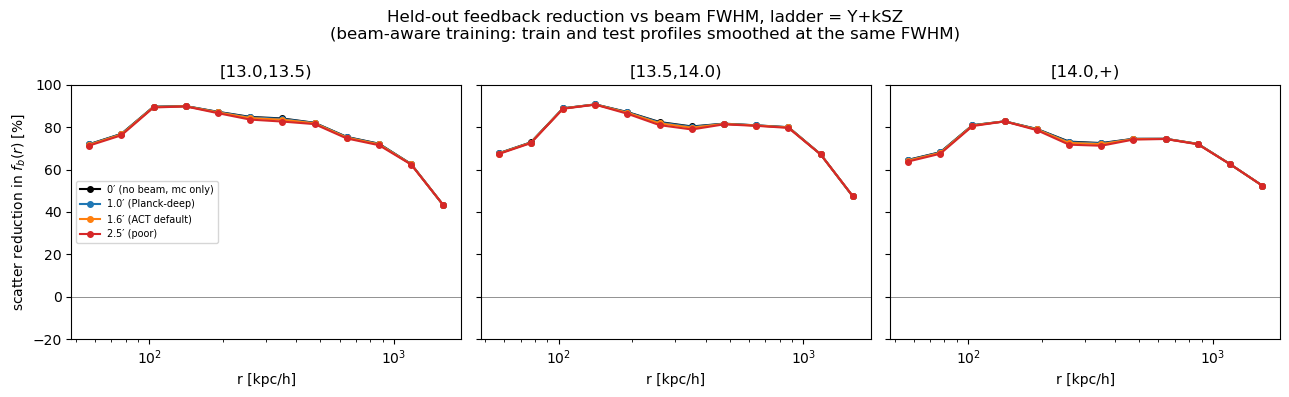

In [15]:
# radial reduction curves at each beam, Y+kSZ ladder
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
BEAM_COLORS = ['k', 'C0', 'C1', 'C3']
for b, (ax, lbl) in enumerate(zip(axes, MLBL)):
    for B_, c in zip(BEAMS, BEAM_COLORS):
        red = red_per_beam[(B_['fwhm'], 'Y+kSZ', lbl)]['red']
        ax.plot(r, red*100, 'o-', color=c, ms=4, label=B_['name'])
    ax.axhline(0, c='0.5', lw=0.6); ax.set_xscale('log')
    ax.set_xlabel('r [kpc/h]'); ax.set_title(lbl); ax.set_ylim(-20, 100)
axes[0].set_ylabel('scatter reduction in $f_b(r)$ [%]'); axes[0].legend(fontsize=7)
fig.suptitle('Held-out feedback reduction vs beam FWHM, ladder = Y+kSZ\n'
             '(beam-aware training: train and test profiles smoothed at the same FWHM)')
fig.tight_layout(); fig.savefig(FIG/'reduction_vs_beam.png', dpi=130)
print('saved reduction_vs_beam.png')

### 4b. Radial structure of the kSZ uplift (ACT 1.6′ beam)
Where in the profile does adding kSZ help? Overlay the held-out reduction
curves for `Y` vs `Y+kSZ` at the 1.6′ beam, per mass bin.


saved ksz_radial_uplift.png


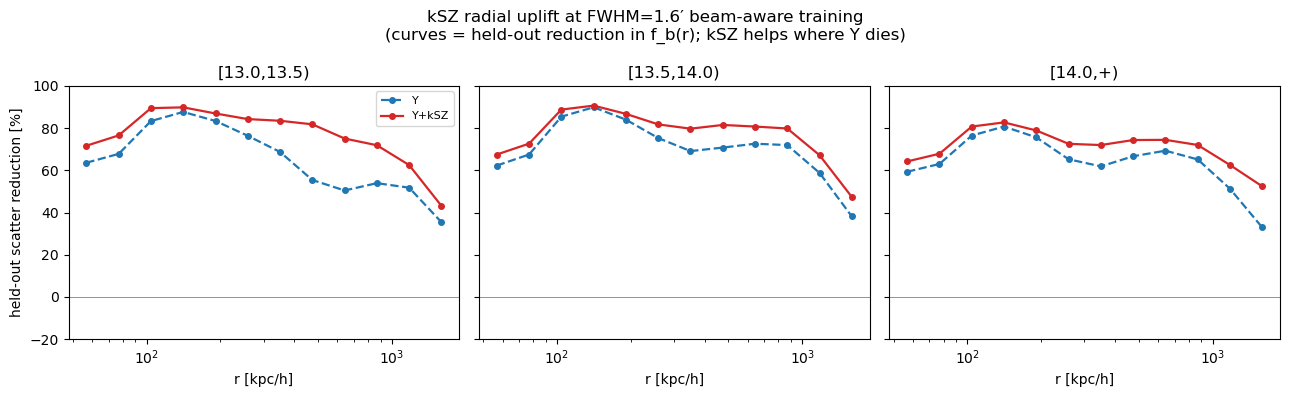

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
ACT_FWHM = 1.6
for b, (ax, lbl) in enumerate(zip(axes, MLBL)):
    for L, c, ls in [('Y', 'C0', '--'), ('Y+kSZ', 'C3', '-')]:
        red = red_per_beam[(ACT_FWHM, L, lbl)]['red']
        ax.plot(r, red*100, ls, marker='o', color=c, ms=4, lw=1.6, label=L)
    ax.axhline(0, c='0.5', lw=0.6); ax.set_xscale('log')
    ax.set_xlabel('r [kpc/h]'); ax.set_title(lbl); ax.set_ylim(-20, 100)
axes[0].set_ylabel('held-out scatter reduction [%]'); axes[0].legend(fontsize=8)
fig.suptitle(f'kSZ radial uplift at FWHM={ACT_FWHM}′ beam-aware training\n'
             '(curves = held-out reduction in f_b(r); kSZ helps where Y dies)')
fig.tight_layout(); fig.savefig(FIG/'ksz_radial_uplift.png', dpi=130)
print('saved ksz_radial_uplift.png')


## 4. Truth recovery vs beam FWHM (the headline experiment)
For each beam: train Ridge on the beam-matched BIND design profiles, feed the
**beam-matched truth** observables with per-radius lognormal noise (same `f_in/f_out`
schedule as v1's realistic regime: 5 → 40 %), Monte-Carlo 200 noise draws, plot
predicted vs CAMELS truth. Compare the beam-aware curves at e.g. 1.6′ to the v1
(beam-naive) curves we recorded last turn.

In [17]:
def train_ridge(Bp, b, cols, alpha=10.0):
    Xtr = _design_features(Bp, cols, b); Ytr = Bp['fb'][:, b, :]
    xs = StandardScaler().fit(Xtr); ys = StandardScaler().fit(Ytr)
    return xs, ys, Ridge(alpha=alpha).fit(xs.transform(Xtr), ys.transform(Ytr))

def predict_truth(Bp, tr, b, cols):
    xs, ys, reg = train_ridge(Bp, b, cols)
    feats = []
    for c in cols:
        v = tr[c][b]; v = np.log10(np.clip(v, 1e-30, None)) if c in LOGFEAT else v
        feats.append(v[None, :])
    X = np.nan_to_num(xs.transform(np.hstack(feats)), nan=0.0)
    return ys.inverse_transform(reg.predict(X))[0]

def eval_truth(Bp_train, tr_test, cols, b, n_seeds=5, n_mc=200,
               f_in=0.05, f_out=0.40, base_seed=42):
    '''Train Ridge once on Bp_train; evaluate against noised tr_test, repeated
    over n_seeds independent noise pools of n_mc draws each. Returns the RMS of
    the seed-averaged mean prediction (tightens the small-RMS noise floor) plus
    the seed-averaged mean curve and 16/84 band across all draws.'''
    seed_means = []
    all_draws = []
    for s in range(n_seeds):
        rng = np.random.default_rng(base_seed + 1000*s)
        draws = []
        for _ in range(n_mc):
            tr_n = {k: tr_test[k].copy() for k in tr_test}
            for c in cols:
                tr_n[c] = np.array([lognormal_noise(tr_n[c][bb], r, f_in, f_out, rng)
                                    for bb in range(3)])
            draws.append(predict_truth(Bp_train, tr_n, b, cols))
        draws = np.asarray(draws)
        seed_means.append(draws.mean(0))
        all_draws.append(draws)
    seed_means = np.asarray(seed_means)
    mean = seed_means.mean(0)
    pooled = np.concatenate(all_draws, 0)
    lo, hi = np.percentile(pooled, [16, 84], 0)
    return mean, lo, hi, seed_means

F_IN, F_OUT, NMC, N_SEEDS = 0.05, 0.40, 200, 5
rms = {}; rms_seed_std = {}; pred_curves = {}; pred_band = {}
for B_ in BEAMS:
    Bp_b = Bp_beam[B_['fwhm']]; tr_b = truth_beam[B_['fwhm']]
    for L, cols in LADDERS.items():
        for b, lbl in enumerate(MLBL):
            mean, lo, hi, sm_ = eval_truth(Bp_b, tr_b, cols, b,
                                            n_seeds=N_SEEDS, n_mc=NMC,
                                            f_in=F_IN, f_out=F_OUT)
            tru = truth['fb'][b]
            rms[(B_['fwhm'], L, lbl)] = float(np.sqrt(np.nanmean((mean - tru)**2)))
            # seed-to-seed scatter on the RMS itself, for the ± below
            rms_per_seed = np.sqrt(np.nanmean((sm_ - tru[None, :])**2, 1))
            rms_seed_std[(B_['fwhm'], L, lbl)] = float(rms_per_seed.std(ddof=1))
            pred_curves[(B_['fwhm'], L, lbl)] = mean
            pred_band[(B_['fwhm'], L, lbl)] = (lo, hi)

print(f'RMS|pred-truth| in f_b (×1e3) ± seed-scatter (N_SEEDS={N_SEEDS}, NMC={NMC})')
print(f'{"beam":24s} {"ladder":8s}'+''.join(f'{l:>16s}' for l in MLBL))
for B_ in BEAMS:
    for L in LADDERS:
        row = f"{B_['name']:24s} {L:8s}"
        for lbl in MLBL:
            v = rms[(B_['fwhm'], L, lbl)]*1e3
            e = rms_seed_std[(B_['fwhm'], L, lbl)]*1e3
            row += f'  {v:6.2f}±{e:4.2f}'
        print(row)


RMS|pred-truth| in f_b (×1e3) ± seed-scatter (N_SEEDS=5, NMC=200)
beam                     ladder       [13.0,13.5)     [13.5,14.0)        [14.0,+)
0′ (no beam, mc only)    Y          12.39±5.07    5.39±2.00    2.69±2.19
0′ (no beam, mc only)    Y+kSZ       2.75±2.22    2.50±1.04    2.73±1.01
1.0′ (Planck-deep)       Y          12.34±5.10    5.47±2.04    2.69±2.16
1.0′ (Planck-deep)       Y+kSZ       2.77±2.28    2.52±1.04    2.71±1.04
1.6′ (ACT default)       Y          12.25±5.13    5.59±2.08    2.68±2.13
1.6′ (ACT default)       Y+kSZ       2.79±2.37    2.56±1.05    2.69±1.09
2.5′ (poor)              Y          12.03±5.10    5.88±2.13    2.68±2.08
2.5′ (poor)              Y+kSZ       2.84±2.58    2.63±1.01    2.66±1.21


saved pred_vs_truth_beam_aware.png


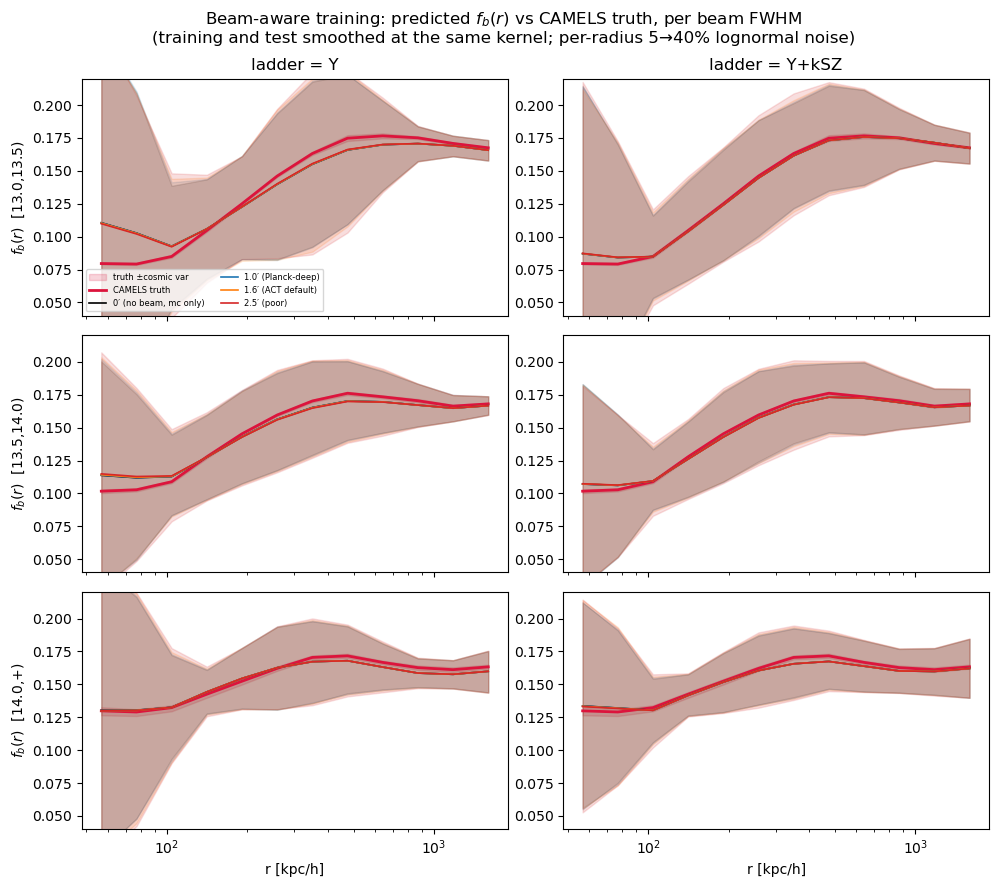

In [18]:
# rows = mass bins, cols = ladders; one panel per (bin, ladder); curves = beam FWHM
fig, axes = plt.subplots(len(MLBL), len(LADDERS), figsize=(10, 9), sharex=True)
for b, lbl in enumerate(MLBL):
    tb = band('fb')[:, b, :]
    for j, L in enumerate(LADDERS):
        ax = axes[b, j]
        ax.fill_between(r, tb[0], tb[1], color='crimson', alpha=0.18,
                        label='truth ±cosmic var' if (b == 0 and j == 0) else None)
        ax.plot(r, truth['fb'][b], '-', c='crimson', lw=2,
                label='CAMELS truth' if (b == 0 and j == 0) else None)
        for B_, c in zip(BEAMS, BEAM_COLORS):
            mean = pred_curves[(B_['fwhm'], L, lbl)]
            lo, hi = pred_band[(B_['fwhm'], L, lbl)]
            ax.plot(r, mean, '-', c=c, lw=1.2, label=B_['name'] if (b == 0 and j == 0) else None)
            ax.fill_between(r, lo, hi, color=c, alpha=0.15)
        ax.set_xscale('log'); ax.set_ylim(0.04, 0.22)
        if b == len(MLBL)-1: ax.set_xlabel('r [kpc/h]')
        if j == 0: ax.set_ylabel(f'$f_b(r)$  {lbl}')
        if b == 0: ax.set_title(f'ladder = {L}')
axes[0, 0].legend(fontsize=6, loc='lower left', ncol=2)
fig.suptitle('Beam-aware training: predicted $f_b(r)$ vs CAMELS truth, per beam FWHM\n'
             '(training and test smoothed at the same kernel; per-radius 5→40% lognormal noise)')
fig.tight_layout(); fig.savefig(FIG/'pred_vs_truth_beam_aware.png', dpi=130)
print('saved pred_vs_truth_beam_aware.png')

## 5. Information-loss curve
Single summary plot: **RMS|pred − truth| as a function of beam FWHM**, ladder = `Y+kSZ`,
per mass bin. The dashed horizontal lines mark `σ_marg` per bin (the no-information
floor: predict the cosmic mean). The FWHM at which the curve crosses `σ_marg` is the
experiment-design number.

saved info_loss_vs_beam.png


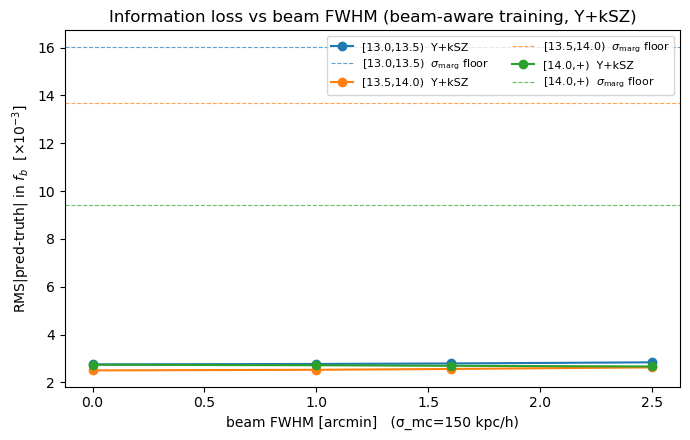

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
fwhm_arr = np.array([B_['fwhm'] for B_ in BEAMS])
BIN_COLORS = ['C0', 'C1', 'C2']
for b, (lbl, c) in enumerate(zip(MLBL, BIN_COLORS)):
    rms_curve = np.array([rms[(fw, 'Y+kSZ', lbl)] for fw in fwhm_arr]) * 1e3
    ax.plot(fwhm_arr, rms_curve, 'o-', color=c, label=f'{lbl}  Y+kSZ')
    sm = np.nanmean(np.nanstd(Bp_clean['fb'][:, b, :], 0)) * 1e3
    ax.axhline(sm, ls='--', c=c, lw=0.8, alpha=0.7,
               label=f'{lbl}  $\\sigma_\\mathrm{{marg}}$ floor')
ax.set_xlabel('beam FWHM [arcmin]   (\u03c3_mc=150 kpc/h)')
ax.set_ylabel('RMS|pred-truth| in $f_b$  [×10$^{-3}$]')
ax.set_title('Information loss vs beam FWHM (beam-aware training, Y+kSZ)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIG/'info_loss_vs_beam.png', dpi=130)
print('saved info_loss_vs_beam.png')

### 5b. σ_mc sweep at fixed 1.6′ beam
At realistic FWHM=1.6′ the kernel is dominated by miscentering (σ_mc=150 kpc/h
adds 150 kpc/h on top of the 53 kpc/h beam). Vary σ_mc with the beam fixed at
1.6′ to expose the centering-accuracy budget — the experimentally actionable
"how well must I centre my stack?" curve.


σ_mc sweep at FWHM=1.6′, Y+kSZ; RMS×1e3 ± seed scatter
  σ_mc [kpc/h]    σ_total     [13.0,13.5)     [13.5,14.0)        [14.0,+)
             0       53.0    2.02±1.31    1.93±0.63    4.32±0.43
            50       72.9    2.21±1.46    1.98±0.67    3.87±0.48
           100      113.2    2.55±1.80    2.20±0.83    3.11±0.72
           150      159.1    2.79±2.37    2.56±1.05    2.69±1.09
           250      255.6    2.84±2.81    3.03±1.05    3.15±1.65
           400      403.5    2.15±1.47    2.40±1.68    4.36±1.32
saved info_loss_vs_sigma_mc.png


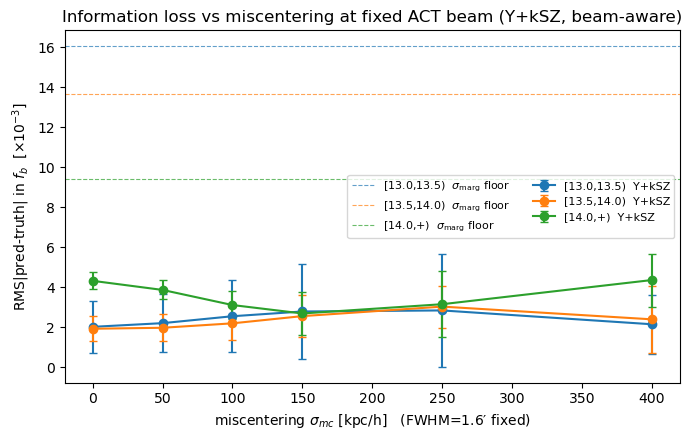

In [20]:
SIGMA_MC_GRID = [0.0, 50.0, 100.0, 150.0, 250.0, 400.0]
ACT_FWHM = 1.6
sigma_beam = ACT_FWHM * 78.0 * FWHM2SIG
def _sigma_total_for(sigma_mc):
    return float(np.sqrt(sigma_beam**2 + sigma_mc**2))

# Pre-build smoothed designs and smoothed truth at each σ_total
Bp_mc, tr_mc, sig_arr = {}, {}, []
for sm_kpc in SIGMA_MC_GRID:
    st = _sigma_total_for(sm_kpc); sig_arr.append(st)
    Bp_mc[sm_kpc] = smooth_designs(Bp_clean, st)
    tr_mc[sm_kpc] = smooth_truth(truth, st)

rms_mc = {}; rms_mc_err = {}
for sm_kpc in SIGMA_MC_GRID:
    for L, cols in LADDERS.items():
        for b, lbl in enumerate(MLBL):
            mean, _, _, sm_ = eval_truth(Bp_mc[sm_kpc], tr_mc[sm_kpc], cols, b,
                                          n_seeds=N_SEEDS, n_mc=NMC,
                                          f_in=F_IN, f_out=F_OUT)
            tru = truth['fb'][b]
            rms_mc[(sm_kpc, L, lbl)] = float(np.sqrt(np.nanmean((mean - tru)**2)))
            rms_mc_err[(sm_kpc, L, lbl)] = float(
                np.sqrt(np.nanmean((sm_ - tru[None, :])**2, 1)).std(ddof=1))

print(f'σ_mc sweep at FWHM={ACT_FWHM}′, Y+kSZ; RMS×1e3 ± seed scatter')
print(f'{"σ_mc [kpc/h]":>14s} {"σ_total":>10s}'+''.join(f'{l:>16s}' for l in MLBL))
for sm_kpc, st in zip(SIGMA_MC_GRID, sig_arr):
    row = f'{sm_kpc:14.0f} {st:10.1f}'
    for lbl in MLBL:
        v = rms_mc[(sm_kpc, 'Y+kSZ', lbl)]*1e3
        e = rms_mc_err[(sm_kpc, 'Y+kSZ', lbl)]*1e3
        row += f'  {v:6.2f}±{e:4.2f}'
    print(row)

fig, ax = plt.subplots(figsize=(7, 4.5))
mc_arr = np.array(SIGMA_MC_GRID)
for b, (lbl, c) in enumerate(zip(MLBL, BIN_COLORS)):
    rms_curve = np.array([rms_mc[(sm, 'Y+kSZ', lbl)] for sm in SIGMA_MC_GRID]) * 1e3
    err_curve = np.array([rms_mc_err[(sm, 'Y+kSZ', lbl)] for sm in SIGMA_MC_GRID]) * 1e3
    ax.errorbar(mc_arr, rms_curve, yerr=err_curve, fmt='o-', color=c,
                label=f'{lbl}  Y+kSZ', capsize=3)
    sm_floor = np.nanmean(np.nanstd(Bp_clean['fb'][:, b, :], 0)) * 1e3
    ax.axhline(sm_floor, ls='--', c=c, lw=0.8, alpha=0.7,
               label=f'{lbl}  $\sigma_\mathrm{{marg}}$ floor')
ax.set_xlabel(f'miscentering $\sigma_{{mc}}$ [kpc/h]   (FWHM={ACT_FWHM}′ fixed)')
ax.set_ylabel('RMS|pred-truth| in $f_b$  [×10$^{-3}$]')
ax.set_title('Information loss vs miscentering at fixed ACT beam (Y+kSZ, beam-aware)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig(FIG/'info_loss_vs_sigma_mc.png', dpi=130)
print('saved info_loss_vs_sigma_mc.png')


## 6. Beam-aware vs beam-naive (the v1 ↔ v2 comparison)
Reproduce the v1 "beam-naive" baseline by training on **clean** BIND profiles and
evaluating on **beamed** truth, side-by-side with the beam-aware result. This is the
single number that tells us whether v2 was worth doing.

In [21]:
rms_naive = {}; rms_naive_seed_std = {}
for B_ in BEAMS:
    tr_b = truth_beam[B_['fwhm']]
    for L, cols in LADDERS.items():
        for b, lbl in enumerate(MLBL):
            mean, _, _, sm_ = eval_truth(Bp_clean, tr_b, cols, b,
                                          n_seeds=N_SEEDS, n_mc=NMC,
                                          f_in=F_IN, f_out=F_OUT)
            tru = truth['fb'][b]
            rms_naive[(B_['fwhm'], L, lbl)] = float(np.sqrt(np.nanmean((mean - tru)**2)))
            rms_naive_seed_std[(B_['fwhm'], L, lbl)] = float(
                np.sqrt(np.nanmean((sm_ - tru[None, :])**2, 1)).std(ddof=1))

print('beam-naive (train on clean) vs beam-aware: RMS|pred-truth| in f_b (×1e3), Y+kSZ')
print(f'{"beam":24s} {"bin":14s} {"naive":>14s} {"aware":>14s} {"Δ":>8s}')
for B_ in BEAMS:
    for lbl in MLBL:
        n = rms_naive[(B_['fwhm'], 'Y+kSZ', lbl)] * 1e3
        en = rms_naive_seed_std[(B_['fwhm'], 'Y+kSZ', lbl)] * 1e3
        a = rms[(B_['fwhm'], 'Y+kSZ', lbl)] * 1e3
        ea = rms_seed_std[(B_['fwhm'], 'Y+kSZ', lbl)] * 1e3
        print(f"{B_['name']:24s} {lbl:14s}  {n:6.2f}±{en:4.2f}  {a:6.2f}±{ea:4.2f}  {a-n:+8.2f}")


beam-naive (train on clean) vs beam-aware: RMS|pred-truth| in f_b (×1e3), Y+kSZ
beam                     bin                     naive          aware        Δ
0′ (no beam, mc only)    [13.0,13.5)      18.57±2.31    2.75±2.22    -15.82
0′ (no beam, mc only)    [13.5,14.0)      31.41±0.85    2.50±1.04    -28.91
0′ (no beam, mc only)    [14.0,+)         37.81±0.50    2.73±1.01    -35.08
1.0′ (Planck-deep)       [13.0,13.5)      19.10±2.31    2.77±2.28    -16.33
1.0′ (Planck-deep)       [13.5,14.0)      32.20±0.85    2.52±1.04    -29.68
1.0′ (Planck-deep)       [14.0,+)         38.63±0.50    2.71±1.04    -35.91
1.6′ (ACT default)       [13.0,13.5)      19.90±2.29    2.79±2.37    -17.11
1.6′ (ACT default)       [13.5,14.0)      33.41±0.84    2.56±1.05    -30.85
1.6′ (ACT default)       [14.0,+)         39.83±0.49    2.69±1.09    -37.14
2.5′ (poor)              [13.0,13.5)      21.68±2.27    2.84±2.58    -18.84
2.5′ (poor)              [13.5,14.0)      36.09±0.83    2.63±1.01    -33.47
2.5′ 

## 7. Save machine-readable results

In [22]:
import json
out = {
    'r_kpc': r.tolist(), 'mass_bins': MLBL,
    'pixel_scale_kpc_h': float(PIX_KPC_H), 'sigma_mc_kpc_h': 150.0,
    'beams': [{'name': B_['name'], 'fwhm_arcmin': B_['fwhm'], 'sigma_total_kpc_h': B_['sigma']}
              for B_ in BEAMS],
    'noise': dict(f_in=F_IN, f_out=F_OUT, n_mc=NMC, n_seeds=N_SEEDS),
    'design_reduction_vs_r': {
        f"{B_['fwhm']}|{L}|{lbl}": red_per_beam[(B_['fwhm'], L, lbl)]['red'].tolist()
        for B_ in BEAMS for L in LADDERS for lbl in MLBL},
    'rms_truth_pred_aware': {
        f"{B_['fwhm']}|{L}|{lbl}": rms[(B_['fwhm'], L, lbl)]
        for B_ in BEAMS for L in LADDERS for lbl in MLBL},
    'rms_truth_pred_aware_seed_std': {
        f"{B_['fwhm']}|{L}|{lbl}": rms_seed_std[(B_['fwhm'], L, lbl)]
        for B_ in BEAMS for L in LADDERS for lbl in MLBL},
    'rms_truth_pred_naive': {
        f"{B_['fwhm']}|{L}|{lbl}": rms_naive[(B_['fwhm'], L, lbl)]
        for B_ in BEAMS for L in LADDERS for lbl in MLBL},
    'rms_truth_pred_naive_seed_std': {
        f"{B_['fwhm']}|{L}|{lbl}": rms_naive_seed_std[(B_['fwhm'], L, lbl)]
        for B_ in BEAMS for L in LADDERS for lbl in MLBL},
    'sigma_mc_sweep': {
        'fwhm_arcmin': ACT_FWHM, 'sigma_mc_grid_kpc_h': list(SIGMA_MC_GRID),
        'sigma_total_kpc_h': sig_arr,
        'rms': {f"{sm}|{L}|{lbl}": rms_mc[(sm, L, lbl)]
                for sm in SIGMA_MC_GRID for L in LADDERS for lbl in MLBL},
        'rms_seed_std': {f"{sm}|{L}|{lbl}": rms_mc_err[(sm, L, lbl)]
                         for sm in SIGMA_MC_GRID for L in LADDERS for lbl in MLBL},
    },
    'truth_fb': {l: truth['fb'][b].tolist() for b, l in enumerate(MLBL)},
}
json.dump(out, open(FIG/'beam_aware_results.json', 'w'), indent=2)
print('wrote', FIG/'beam_aware_results.json')


wrote figures/observable_fb_beam_aware/beam_aware_results.json


## 8. How to read this notebook

- **§3 table.** Held-out feedback reduction at each beam tells you how much information
  the smoothing alone removes — a ceiling on what any retrained map can achieve.
- **§4 table** + figure. The actual recovered RMS against CAMELS truth, per beam, per
  ladder. The Y+kSZ row at 1.6′ should be compared to the v1 number (`profile_fb_ysz_ksz`
  §5: 21.4 / 36.9 / 41.9 ×10⁻³ in the three bins).
- **§5 figure.** The single experiment-design plot: RMS vs beam FWHM with the `σ_marg`
  floor. Where the curve dives below the floor is the beam at which feedback information
  becomes meaningfully recoverable from the stack.
- **§6 table.** Beam-naive vs beam-aware. If Δ is large and negative, beam-aware training
  is delivering; if Δ ≈ 0 the brittleness was elsewhere (likely kSZ noise model or the
  miscentering tail).

All caveats from `profile_fb_ysz_ksz.ipynb` §7 carry over unchanged.